# Machine Learning Foundation

## Course 3, Part a: Logistic Regression LAB


## Introduction

We will be using the [Human Activity Recognition with Smartphones](https://archive.ics.uci.edu/ml/datasets/Human+Activity+Recognition+Using+Smartphones) database, which was built from the recordings of study participants who carried a smartphone with an embedded inertial sensor while performing activities of daily living (ADL). The objective is to classify the activities the participants performed into one of the six following categories: walking, walking upstairs, walking downstairs, sitting, standing, and laying.

The following information is provided for each record in the dataset:

- Triaxial acceleration from the accelerometer (total acceleration) and the estimated body acceleration
- Triaxial Angular velocity from the gyroscope
- A 561-feature vector with time and frequency domain variables
- The activity label

More information about the features are available on the website linked above.


In [1]:
!pip install seaborn
!pip install pandas
!pip install numpy
!pip install  matplotlib
!pip install scikit-learn

In [2]:
def warn(*args, **kwargs):
    pass
import warnings
warnings.warn = warn

In [3]:
import seaborn as sns, pandas as pd, numpy as np

## Question 1

Import the data and do the following:

* Examine the data types--there are many columns, so it might be wise to use value counts.
* Determine if the floating point values need to be scaled.
* Determine the breakdown of each activity.
* Encode the activity label as an integer.


In [4]:
### BEGIN SOLUTION
data = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/Human_Activity_Recognition_Using_Smartphones_Data.csv", sep=',')

The data columns are all floats except for the activity label.


In [5]:
data.dtypes.value_counts()

,count
float64,561
object,1


In [6]:
data.dtypes.tail()

,0
"angle(tBodyGyroJerkMean,gravityMean)",float64
"angle(X,gravityMean)",float64
"angle(Y,gravityMean)",float64
"angle(Z,gravityMean)",float64
Activity,object


The data are all scaled from -1 (minimum) to 1.0 (maximum).


In [7]:
data.head()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)",Activity
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627,STANDING
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317,STANDING
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118,STANDING
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663,STANDING
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892,STANDING


In [8]:
data.iloc[:, :-1].min().value_counts()

,count
-1.0,561


In [9]:
data.iloc[:, :-1].max().value_counts()

,count
1.0,561


Examine the breakdown of activities; they are relatively balanced.


In [10]:
data.Activity.value_counts()

,count
Activity,
LAYING,1944
STANDING,1906
SITTING,1777
WALKING,1722
WALKING_UPSTAIRS,1544
WALKING_DOWNSTAIRS,1406


Scikit learn classifiers won't accept a sparse matrix for the prediction column. Thus, either `LabelEncoder` needs to be used to convert the activity labels to integers, or if `DictVectorizer` is used, the resulting matrix must be converted to a non-sparse array.  
Use `LabelEncoder` to fit_transform the "Activity" column, and look at 5 random values.


In [11]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
data['Activity'] = le.fit_transform(data.Activity)
data['Activity'].sample(5)
### END SOLUTION

,Activity
2656,3
9050,2
7886,0
3770,5
9341,5


## Question 2

* Calculate the correlations between the dependent variables.
* Create a histogram of the correlation values.
* Identify those that are most correlated (either positively or negatively).


In [12]:
### BEGIN SOLUTION
# Calculate the correlation values
feature_cols = data.columns[:-1]
corr_values = data[feature_cols].corr()

# Simplify by emptying all the data below the diagonal
tril_index = np.tril_indices_from(corr_values)

# Make the unused values NaNs
for coord in zip(*tril_index):
    corr_values.iloc[coord[0], coord[1]] = np.nan

# Stack the data and convert to a data frame
corr_values = (corr_values
               .stack()
               .to_frame()
               .reset_index()
               .rename(columns={'level_0':'feature1',
                                'level_1':'feature2',
                                0:'correlation'}))

# Get the absolute values for sorting
corr_values['abs_correlation'] = corr_values.correlation.abs()

A histogram of the absolute value correlations.


In [13]:
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

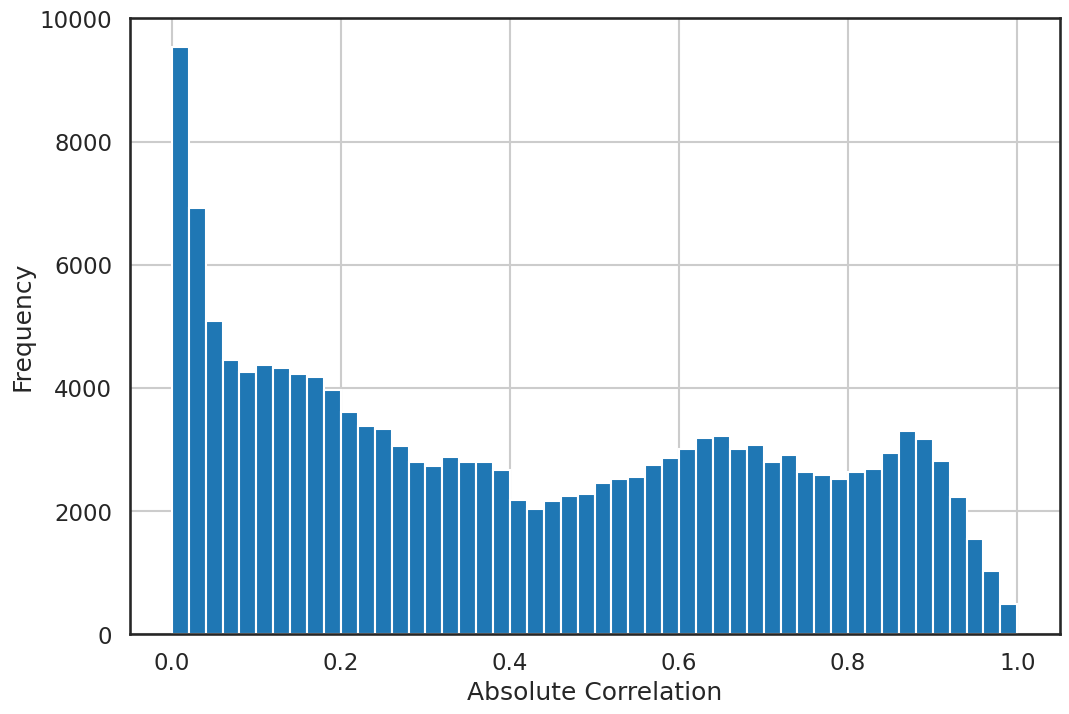

In [14]:
sns.set_context('talk')
sns.set_style('white')

ax = corr_values.abs_correlation.hist(bins=50, figsize=(12, 8))
ax.set(xlabel='Absolute Correlation', ylabel='Frequency');

In [15]:
# The most highly correlated values
corr_values.sort_values('correlation', ascending=False).query('abs_correlation>0.8')
### END SOLUTION

,feature1,feature2,correlation,abs_correlation
156894,fBodyBodyGyroJerkMag-mean(),fBodyBodyGyroJerkMag-sma(),1.000000,1.000000
156556,fBodyBodyGyroMag-mean(),fBodyBodyGyroMag-sma(),1.000000,1.000000
96706,tGravityAccMag-mean(),tGravityAccMag-sma(),1.000000,1.000000
96366,tBodyAccMag-arCoeff()4,tGravityAccMag-arCoeff()4,1.000000,1.000000
109498,tBodyGyroJerkMag-mean(),tBodyGyroJerkMag-sma(),1.000000,1.000000
...,...,...,...,...
22657,tGravityAcc-mean()-Y,"angle(Y,gravityMean)",-0.993425,0.993425
39225,"tGravityAcc-arCoeff()-Z,3","tGravityAcc-arCoeff()-Z,4",-0.994267,0.994267
38739,"tGravityAcc-arCoeff()-Z,2","tGravityAcc-arCoeff()-Z,3",-0.994628,0.994628
23176,tGravityAcc-mean()-Z,"angle(Z,gravityMean)",-0.994764,0.994764


## Question 3

* Split the data into train and test data sets. This can be done using any method, but consider using Scikit-learn's `StratifiedShuffleSplit` to maintain the same ratio of predictor classes.
* Regardless of the method used to split the data, compare the ratio of classes in both the train and test splits.


In [16]:
### BEGIN SOLUTION
from sklearn.model_selection import StratifiedShuffleSplit

# Get the split indexes
strat_shuf_split = StratifiedShuffleSplit(n_splits=1,
                                          test_size=0.3,
                                          random_state=42)

train_idx, test_idx = next(strat_shuf_split.split(data[feature_cols], data.Activity))

# Create the dataframes
X_train = data.loc[train_idx, feature_cols]
y_train = data.loc[train_idx, 'Activity']

X_test  = data.loc[test_idx, feature_cols]
y_test  = data.loc[test_idx, 'Activity']

In [17]:
y_train.value_counts(normalize=True)

,proportion
Activity,
0,0.188792
2,0.185046
1,0.172562
3,0.167152
5,0.149951
4,0.136496


In [18]:
y_test.value_counts(normalize=True)
### END SOLUTION

,proportion
Activity,
0,0.188673
2,0.185113
1,0.172492
3,0.167314
5,0.149838
4,0.136570


## Question 4

* Fit a logistic regression model without any regularization using all of the features. Be sure to read the documentation about fitting a multi-class model so you understand the coefficient output. Store the model.
* Using cross validation to determine the hyperparameters and fit models using L1 and L2 regularization. Store each of these models as well. Note the limitations on multi-class models, solvers, and regularizations. The regularized models, in particular the L1 model, will probably take a while to fit.


In [19]:
### BEGIN SOLUTION
from sklearn.linear_model import LogisticRegression

# Standard logistic regression
lr = LogisticRegression(solver='liblinear').fit(X_train, y_train)

In [20]:
from sklearn.linear_model import LogisticRegressionCV

# L1 regularized logistic regression
lr_l1 = LogisticRegressionCV(Cs=10, cv=4, penalty='l1', solver='liblinear').fit(X_train, y_train)

In [21]:
# L2 regularized logistic regression
lr_l2 = LogisticRegressionCV(Cs=10, cv=4, penalty='l2', solver='liblinear').fit(X_train, y_train)
### END SOLUTION

The code in cells 19, 20, and 21 (97a66223-4449-4f9c-a1cd-2cb13446ae7c, 7P1uN7SdmnJw, and 976605e2-0ec6-4075-a245-9b66b6867437) focuses on fitting different types of logistic regression models to the training data (`X_train`, `y_train`).

*   **Cell 19 (97a66223-4449-4f9c-a1cd-2cb13446ae7c): Standard Logistic Regression**
    *   This cell initializes and fits a basic `LogisticRegression` model from `sklearn.linear_model`. The `solver='liblinear'` parameter is specified, which is a good choice for smaller datasets and for handling both L1 and L2 regularization. Importantly, no regularization is applied in this initial model, providing a baseline.

*   **Cell 20 (7P1uN7SdmnJw): L1 Regularized Logistic Regression (Lasso)**
    *   This cell uses `LogisticRegressionCV` to fit a logistic regression model with L1 regularization. `LogisticRegressionCV` automatically performs cross-validation (`cv=4`) to find the optimal regularization strength (`C`). The `penalty='l1'` argument enables L1 regularization, which encourages sparsity in the coefficients (i.e., some coefficients become exactly zero), effectively performing feature selection. `Cs=10` indicates that 10 different inverse regularization strengths will be tested during cross-validation.

*   **Cell 21 (976605e2-0ec6-4075-a724-d813d155e035): L2 Regularized Logistic Regression (Ridge)**
    *   Similar to cell 20, this cell uses `LogisticRegressionCV` but with L2 regularization (`penalty='l2'`). L2 regularization penalizes the sum of the squares of the coefficients, leading to smaller, but typically non-zero, coefficients. It helps prevent overfitting by shrinking the coefficients towards zero, distributing the impact more evenly across features. Again, `cv=4` for cross-validation and `Cs=10` for testing different regularization strengths are used.

In [ ]:
The code in cells 19, 20, and 21 (97a66223-4449-4f9c-a1cd-2cb13446ae7c, 7P1uN7SdmnJw, and 976605e2-0ec6-4075-a245-9b66b6867437) focuses on fitting different types of logistic regression models to the training data (`X_train`, `y_train`).

*   **Cell 19 (97a66223-4449-4f9c-a1cd-2cb13446ae7c): Standard Logistic Regression**
    *   This cell initializes and fits a basic `LogisticRegression` model from `sklearn.linear_model`. The `solver='liblinear'` parameter is specified, which is a good choice for smaller datasets and for handling both L1 and L2 regularization. Importantly, no regularization is applied in this initial model, providing a baseline.

*   **Cell 20 (7P1uN7SdmnJw): L1 Regularized Logistic Regression (Lasso)**
    *   This cell uses `LogisticRegressionCV` to fit a logistic regression model with L1 regularization. `LogisticRegressionCV` automatically performs cross-validation (`cv=4`) to find the optimal regularization strength (`C`). The `penalty='l1'` argument enables L1 regularization, which encourages sparsity in the coefficients (i.e., some coefficients become exactly zero), effectively performing feature selection. `Cs=10` indicates that 10 different inverse regularization strengths will be tested during cross-validation.

*   **Cell 21 (976605e2-0ec6-4075-a724-d813d155e035): L2 Regularized Logistic Regression (Ridge)**
    *   Similar to cell 20, this cell uses `LogisticRegressionCV` but with L2 regularization (`penalty='l2'`). L2 regularization penalizes the sum of the squares of the coefficients, leading to smaller, but typically non-zero, coefficients. It helps prevent overfitting by shrinking the coefficients towards zero, distributing the impact more evenly across features. Again, `cv=4` for cross-validation and `Cs=10` for testing different regularization strengths are used.

## Question 5

* Compare the magnitudes of the coefficients for each of the models. If one-vs-rest fitting was used, each set of coefficients can be plotted separately.


In [22]:
### BEGIN SOLUTION
# Combine all the coefficients into a dataframe
coefficients = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    coeffs = mod.coef_
    coeff_label = pd.MultiIndex(levels=[[lab], [0,1,2,3,4,5]],
                                 codes=[[0,0,0,0,0,0], [0,1,2,3,4,5]])
    coefficients.append(pd.DataFrame(coeffs.T, columns=coeff_label))

coefficients = pd.concat(coefficients, axis=1)

coefficients.sample(10)

lr                                                          l1  \
            0         1         2         3         4         5         0   
480  0.001270  0.223911  0.193147 -0.099861  0.226713  0.185363 -0.145795   
116  0.218578 -0.285162  0.074299  0.273388 -0.037486 -0.147463  0.707356   
43   0.176507  0.192096  0.463288  0.213429 -0.400604 -0.095164  0.136035   
173  0.012576 -0.029623 -0.245612 -0.074204 -0.378928  0.531937  0.003314   
302  0.011181 -0.156278 -0.028038 -0.974867  0.624226 -0.274065 -0.032459   
500 -0.027802  0.029591  0.193358 -0.111716 -0.079551  0.173281 -0.050622   
466  0.001153  0.188106  0.269344  0.162086 -0.093505  0.262187 -0.000947   
471  0.001967  0.201009  0.286703  0.114569 -0.008619  0.251072 -0.224708   
367 -0.082711 -0.046522  0.176197  1.004514  0.226337  0.515784  0.052738   
264 -0.046754  0.653926 -0.583979  0.036380 -0.269136  0.354203 -0.504761   

                                                             l2            \
            1         2         3         4         5         0         1   
480  0.118285  0.070244  0.000000  0.137067  0.205335 -0.018439  0.582460   
116 -0.132369  0.000000  0.000000  0.000000 -1.235086  0.380329 -0.360374   
43   0.017088  1.007790  0.060847 -0.013332 -0.103929  0.294196  0.194508   
173  0.000000 -0.093268  0.000000 -0.519076  0.899142  0.033489 -0.608206   
302  0.000000  0.000000 -0.943820  0.665706 -0.447407  0.008960 -0.542447   
500  0.000462  0.000000  0.000000  0.000000  0.029215 -0.056520 -0.031417   
466  0.036533  0.338221  0.149284  0.016437  0.322967 -0.018476  0.310757   
471  0.096957  0.493068  0.000000  0.040356  0.399260 -0.017112  0.406862   
367  0.000000  0.000000  2.742633  0.308968  1.609165 -0.089341  1.052094   
264  0.452944  0.000000  0.000000 -0.550985  0.146670 -0.090256  0.970179   

                                             
            2         3         4         5  
480  0.202132 -0.246495  0.343172  0.331362  
116  0.093405  0.841307 -0.063978 -0.195028  
43   0.747507  0.674822 -0.929096 -0.549824  
173 -0.321561 -0.218336 -0.762503  1.811910  
302 -0.067314 -2.359591  0.994769 -0.529913  
500  0.313141 -0.270223 -0.139469  0.245418  
466  0.359038  0.323462 -0.156239  0.405341  
471  0.389302  0.156398  0.039537  0.329643  
367  0.269222  2.811412  0.630742  0.965293  
264 -0.557666  0.229856 -0.621205  0.756498

Prepare six separate plots for each of the multi-class coefficients.


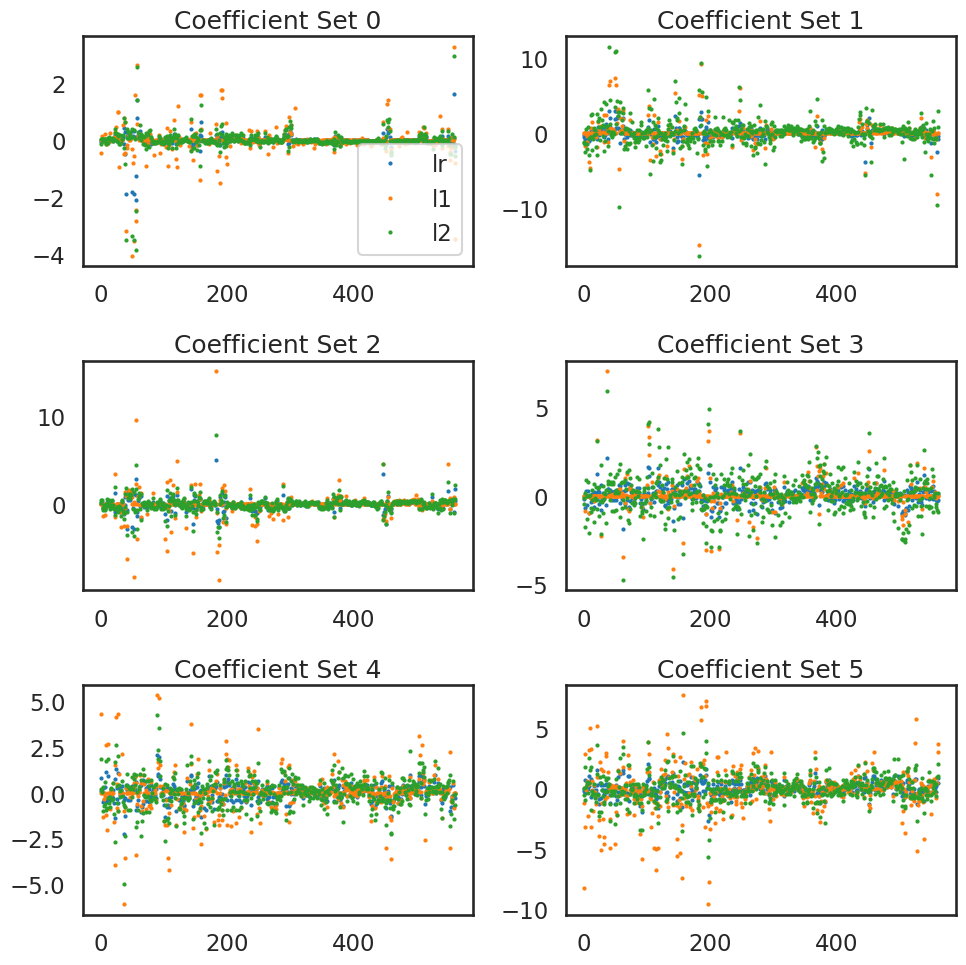

In [23]:
fig, axList = plt.subplots(nrows=3, ncols=2)
axList = axList.flatten()
fig.set_size_inches(10,10)

for ax in enumerate(axList):
    loc = ax[0]
    ax = ax[1]

    data = coefficients.xs(loc, level=1, axis=1)
    data.plot(marker='o', ls='', ms=2.0, ax=ax, legend=False)

    if ax is axList[0]:
        ax.legend(loc=4)

    ax.set(title='Coefficient Set '+str(loc))

plt.tight_layout()
### END SOLUTION

## Question 6

* Predict and store the class for each model.
* Store the probability for the predicted class for each model.


In [24]:
### BEGIN SOLUTION
# Predict the class and the probability for each
y_pred = list()
y_prob = list()

coeff_labels = ['lr', 'l1', 'l2']
coeff_models = [lr, lr_l1, lr_l2]

for lab,mod in zip(coeff_labels, coeff_models):
    y_pred.append(pd.Series(mod.predict(X_test), name=lab))
    y_prob.append(pd.Series(mod.predict_proba(X_test).max(axis=1), name=lab))

y_pred = pd.concat(y_pred, axis=1)
y_prob = pd.concat(y_prob, axis=1)

y_pred.head()

,lr,l1,l2
0,3,3,3
1,5,5,5
2,3,3,3
3,1,1,1
4,0,0,0


In [25]:
y_prob.head()
### END SOLUTION

,lr,l1,l2
0,0.998939,0.998947,0.999757
1,0.988165,0.999517,0.999489
2,0.987592,0.995454,0.999657
3,0.981381,0.999170,0.994339
4,0.998277,0.999924,0.999997


## Question 7

For each model, calculate the following error metrics:

* Accuracy
* Precision
* Recall
* F-score
* Confusion Matrix

Decide how to combine the multi-class metrics into a single value for each model.


In [26]:
### BEGIN SOLUTION
from sklearn.metrics import precision_recall_fscore_support as score
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score
from sklearn.preprocessing import label_binarize

metrics = list()
cm = dict()

for lab in coeff_labels:

    # Preciision, recall, f-score from the multi-class support function
    precision, recall, fscore, _ = score(y_test, y_pred[lab], average='weighted')

    # The usual way to calculate accuracy
    accuracy = accuracy_score(y_test, y_pred[lab])

    # ROC-AUC scores can be calculated by binarizing the data
    auc = roc_auc_score(label_binarize(y_test, classes=[0,1,2,3,4,5]),
              label_binarize(y_pred[lab], classes=[0,1,2,3,4,5]),
              average='weighted')

    # Last, the confusion matrix
    cm[lab] = confusion_matrix(y_test, y_pred[lab])

    metrics.append(pd.Series({'precision':precision, 'recall':recall,
                              'fscore':fscore, 'accuracy':accuracy,
                              'auc':auc},
                             name=lab))

metrics = pd.concat(metrics, axis=1)

In [27]:
metrics
### END SOLUTION

,lr,l1,l2
precision,0.984144,0.983514,0.983824
recall,0.984142,0.983495,0.983819
fscore,0.984143,0.983492,0.983819
accuracy,0.984142,0.983495,0.983819
auc,0.990384,0.989949,0.990165


## Question 8

* Display or plot the confusion matrix for each model.


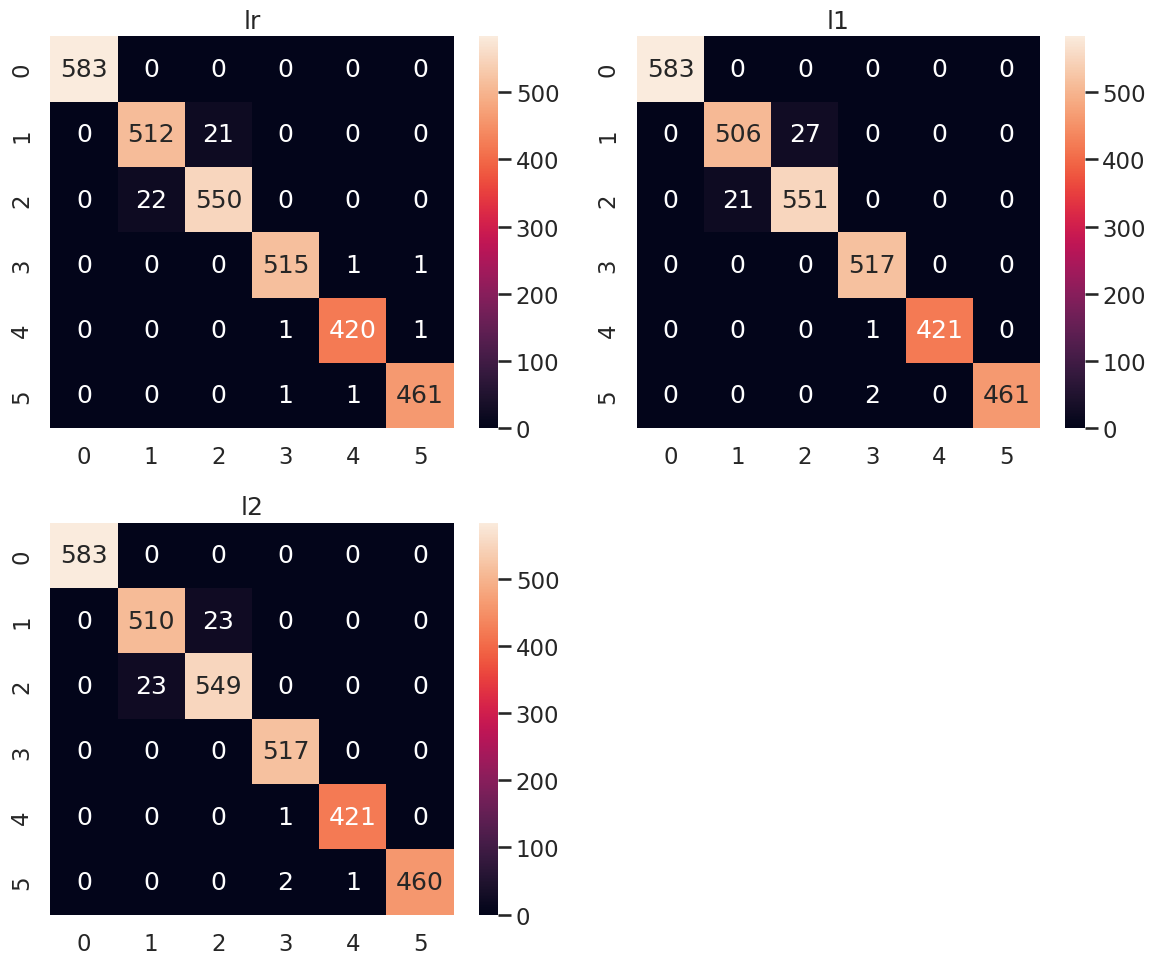

In [28]:
### BEGIN SOLUTION
fig, axList = plt.subplots(nrows=2, ncols=2)
axList = axList.flatten()
fig.set_size_inches(12, 10)

axList[-1].axis('off')

for ax,lab in zip(axList[:-1], coeff_labels):
    sns.heatmap(cm[lab], ax=ax, annot=True, fmt='d');
    ax.set(title=lab);

plt.tight_layout()
### END SOLUTION

---
### Machine Learning Foundation (C) 2020 IBM Corporation
